# Proyek Analisis Data: Brazilian E-Commerce
- **Nama:** Naura Fathiahaq Nabila
- **Email:** naurafathiahaq@gmail.com
- **ID Dicoding:** naurafathiahaq

## Menentukan Pertanyaan Bisnis

- Negara bagian (state) dan kota mana yang memiliki konsentrasi pelanggan tertinggi?
- Berapa banyak pelanggan yang melakukan pembelian lebih dari satu kali (Repeat Order) dan kota mana yang memiliki repeat buyers terbanyak?
- Apakah pelanggan di negara bagian tertentu cenderung memberikan skor review yang lebih rendah karena durasi pengiriman yang lama?




## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
customers = pd.read_csv('customers_dataset.csv')
orders = pd.read_csv('orders_dataset.csv')
items = pd.read_csv('order_items_dataset.csv')
products = pd.read_csv('products_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')
payments = pd.read_csv('order_payments_dataset.csv')
reviews = pd.read_csv('order_reviews_dataset.csv')
geolocation = pd.read_csv('geolocation_dataset.csv')


**Insight:**
- Pada tahap ini mengnpulkan seluruh dataset yang dibutuhkan untuk project yang terdiri dari dataset customer, dataset order, data set item, product, product category, payment, reviews, dan dataset geolocation
-

### Assessing Data

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()
customers.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.info()
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [7]:
orders.duplicated().sum()

np.int64(0)

In [8]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
items.info()
items.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [10]:
items.duplicated().sum()

np.int64(0)

In [11]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
products.info()
products.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [13]:
products.duplicated().sum()

np.int64(0)

In [14]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [15]:
category_translation.info()
category_translation.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,0
product_category_name,0
product_category_name_english,0


In [16]:
category_translation.duplicated().sum()

np.int64(0)

In [17]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [18]:
payments.info()
payments.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [19]:
payments.duplicated().sum()

np.int64(0)

In [20]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [21]:
reviews.info()
reviews.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [22]:
reviews.duplicated().sum()

np.int64(0)

In [23]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [24]:
reviews.info()
reviews.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [25]:
reviews.duplicated().sum()

np.int64(0)

In [26]:
# Melihat apakah data yang kosong itu karena pesanannya dibatalkan (canceled)
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


**Insight:**
- Berdasarkan order status, order_status yang sudah "shipped" sebanyak 1107, status "cancelled" sebanyak 619, "delivered" sbanyak 8, dan "approved" sebanyak 2
- dataset pada proyek ini cenderung lengkap dengan nilai null hanya terdapat pada kolom review_comment_message dan review_comment_message

### Cleaning Data

In [27]:
#mengubah tipe kolom menjadi timestamp
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders[column] = pd.to_datetime(orders[column])

In [28]:
#mengubah tipe kolom menjadi timestamp
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

In [29]:
#mengubah tipe kolom menjadi timestamp
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [30]:
# Mapping singkatan ke nama lengkap Negara Bagian Brazil
state_map = {
'AC': 'Acre', 'AL': 'Alagoas', 'AM': 'Amazonas', 'AP': 'Amapá',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MG': 'Minas Gerais', 'MS': 'Mato Grosso do Sul',
    'MT': 'Mato Grosso', 'PA': 'Pará', 'PB': 'Paraíba', 'PE': 'Pernambuco',
    'PI': 'Piauí', 'PR': 'Paraná', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RO': 'Rondônia', 'RR': 'Roraima', 'RS': 'Rio Grande do Sul', 'SC': 'Santa Catarina',
    'SE': 'Sergipe', 'SP': 'São Paulo', 'TO': 'Tocantins'
}
customers['state_name'] = customers['customer_state'].map(state_map)

In [31]:
orders["delivery_time"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

**Insight:**
- setelah melakukan mapping state, diketahui ternyata dataset ini mengambil data dari berbagai daerah di brazil yang memiliki customer e-commerce ini

## Exploratory Data Analysis (EDA)

### Explore ...

In [32]:
main_df = pd.merge(orders, customers, on="customer_id", how="left")

main_df = pd.merge(main_df, items, on="order_id", how="left")

main_df = pd.merge(main_df, reviews, on="order_id", how="left")

main_df = pd.merge(main_df, products, on="product_id", how="left")
main_df = pd.merge(main_df, category_translation, on="product_category_name", how="left")

In [33]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,...,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,...,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,...,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,...,2017-12-05 19:21:58,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,...,2018-02-18 13:02:51,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [34]:
main_df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,...,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
114087,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,da62f9e57a76d978d02ab5362c509660,...,2018-03-02 17:50:01,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,baby
114088,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,737520a9aad80b3fbbdad19b66b37b30,...,2017-09-22 23:10:57,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2
114089,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,5097a5312c8b157bb7be58ae360ef43c,...,2018-01-27 09:16:56,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
114090,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,5097a5312c8b157bb7be58ae360ef43c,...,2018-01-27 09:16:56,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
114091,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,7.0,60350aa974b26ff12caad89e55993bd6,...,2018-03-17 16:33:31,beleza_saude,45.0,569.0,1.0,150.0,16.0,7.0,15.0,health_beauty


In [35]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114092 non-null  object        
 1   customer_id                    114092 non-null  object        
 2   order_status                   114092 non-null  object        
 3   order_purchase_timestamp       114092 non-null  datetime64[ns]
 4   order_approved_at              113930 non-null  datetime64[ns]
 5   order_delivered_carrier_date   112112 non-null  datetime64[ns]
 6   order_delivered_customer_date  110839 non-null  datetime64[ns]
 7   order_estimated_delivery_date  114092 non-null  datetime64[ns]
 8   delivery_time                  110839 non-null  float64       
 9   customer_unique_id             114092 non-null  object        
 10  customer_zip_code_prefix       114092 non-null  int64         
 11  

In [36]:
state_customers = main_df.groupby('state_name')['customer_id'].nunique().sort_values(ascending=False).reset_index()
state_customers.columns = ['state_name', 'unique_customers']

In [37]:
print("5 Negara Bagian dengan Pelanggan Terbanyak:")
print(state_customers.head(5))

5 Negara Bagian dengan Pelanggan Terbanyak:
          state_name  unique_customers
0          São Paulo             41746
1     Rio de Janeiro             12852
2       Minas Gerais             11635
3  Rio Grande do Sul              5466
4             Paraná              5045


In [38]:
# Membuat kolom kuartal
main_df['order_quarter'] = main_df['order_purchase_timestamp'].dt.to_period('Q').astype(str)

In [39]:
# Filter hanya tahun 2017 dan 2018
quarterly_trend = main_df[main_df['order_purchase_timestamp'].dt.year.isin([2016,2017, 2018])]
quarterly_trend = quarterly_trend.groupby('order_quarter').order_id.nunique().reset_index()
quarterly_trend.columns = ['quarter', 'order_count']

In [40]:
# Menghitung rata-rata durasi pengiriman dan skor review per negara bagian
delivery_review_analysis = main_df.groupby('customer_state').agg({
    'delivery_time': 'mean',
    'review_score': 'mean'
}).reset_index()

In [41]:
# Menampilkan korelasi angka
correlation = delivery_review_analysis['delivery_time'].corr(delivery_review_analysis['review_score'])
print(f"Korelasi antara Durasi Pengiriman dan Skor Review: {correlation:.2f}")

Korelasi antara Durasi Pengiriman dan Skor Review: -0.39


**Insight:**
- Sao Paulo memberikan skor review rata-rata, total order terbesar di brazil untuk e commerce dan memilliki avg_delivery_time terendah
- Sedangkan di bagian Roraima, avg_delivery_time ke daerah mereka aling tinggi, yaitu sebesar 28,975, daerah ini memberikan skor revew kepada e-commerce ini paling rendah yaitu hhanya 3,9 saja dan memilki total order terendah yyaitu hanya 41 kali pemesanan.

## **Visualization & Explanatory Analysis**

### Pertanyaan 1:Negara bagian (state) mana yang memberikan kontribusi jumlah pelanggan unik terbesar sepanjang operasional tahun 2016 hingga 2018?

/tmp/ipython-input-8104/341523559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


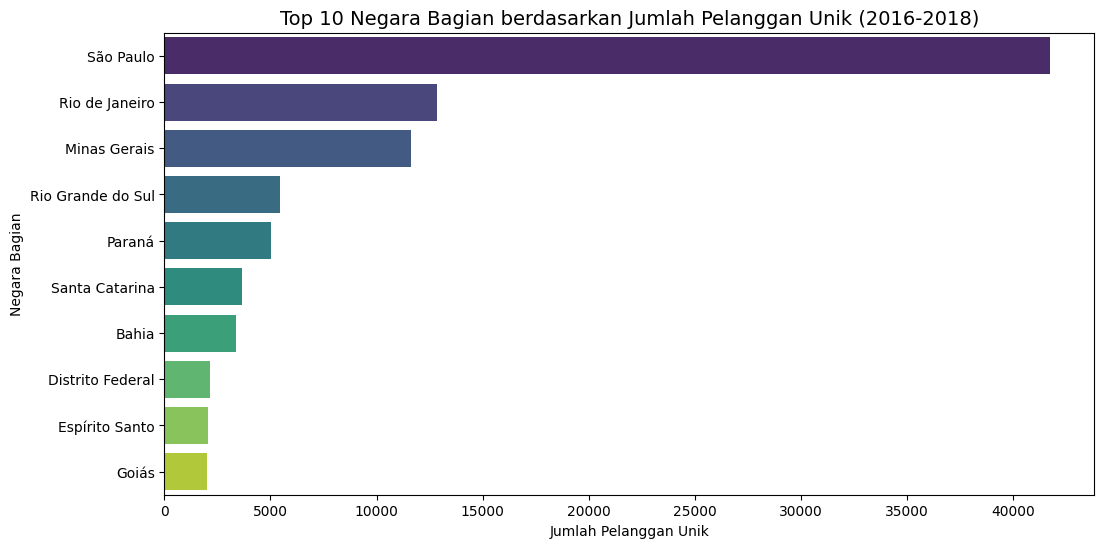

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="unique_customers",
    y="state_name",
    data=state_customers.head(10),
    palette="viridis"
)
plt.title("Top 10 Negara Bagian berdasarkan Jumlah Pelanggan Unik (2016-2018)", fontsize=14)
plt.xlabel("Jumlah Pelanggan Unik")
plt.ylabel("Negara Bagian")
plt.show()

### Pertanyaan 2: Bagaimana tren jumlah pesanan pelanggan di setiap kuartal (quarterly) pada tahun 2017 dan 2018 untuk mengidentifikasi periode puncak (peak season)?

In [43]:
# Menghitung jumlah pesanan per pelanggan unik
user_order_counts = main_df.groupby('customer_unique_id').agg({
    'order_id': 'nunique'
}).reset_index()

user_order_counts.columns = ['customer_unique_id', 'order_count']

# Mengelompokkan menjadi dua kategori
one_time_buyers = user_order_counts[user_order_counts['order_count'] == 1].shape[0]
repeat_buyers = user_order_counts[user_order_counts['order_count'] > 1].shape[0]

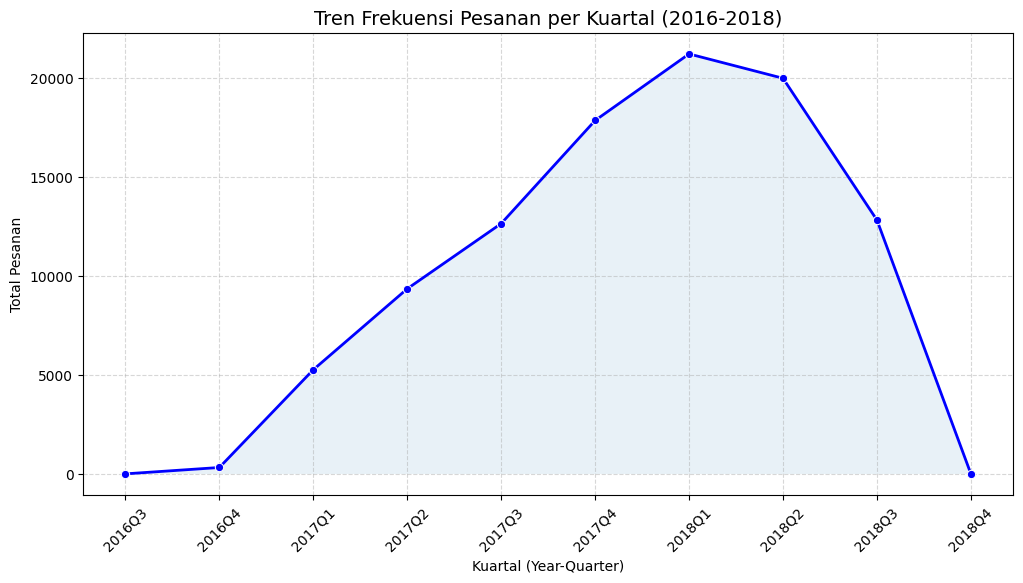

In [44]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=quarterly_trend,
    x='quarter',
    y='order_count',
    marker='o',
    linewidth=2,
    color='blue'
)
plt.fill_between(quarterly_trend['quarter'], quarterly_trend['order_count'], alpha=0.1)
plt.title("Tren Frekuensi Pesanan per Kuartal (2016-2018)", fontsize=14)
plt.xlabel("Kuartal (Year-Quarter)")
plt.ylabel("Total Pesanan")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Pertabyaan 3: Apakah terdapat perbedaan signifikan pada rata-rata durasi pengiriman antar negara bagian, dan bagaimana dampaknya terhadap skor review pelanggan?

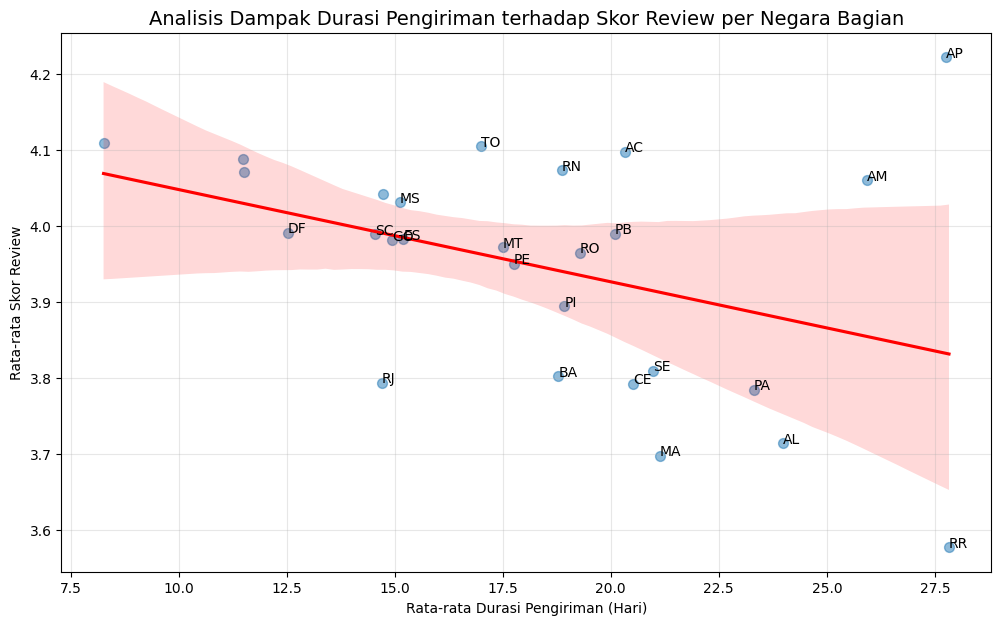

In [45]:
plt.figure(figsize=(12, 7))
sns.regplot(
    data=delivery_review_analysis,
    x='delivery_time',
    y='review_score',
    scatter_kws={'s': 50, 'alpha': 0.5},
    line_kws={'color': 'red'}
)

# Menambahkan label untuk mempermudah identifikasi state ekstrem
for i, txt in enumerate(delivery_review_analysis['customer_state']):
    if delivery_review_analysis['delivery_time'][i] > 15 or delivery_review_analysis['review_score'][i] < 4:
        plt.annotate(txt, (delivery_review_analysis['delivery_time'][i], delivery_review_analysis['review_score'][i]))

plt.title("Analisis Dampak Durasi Pengiriman terhadap Skor Review per Negara Bagian", fontsize=14)
plt.xlabel("Rata-rata Durasi Pengiriman (Hari)")
plt.ylabel("Rata-rata Skor Review")
plt.grid(True, alpha=0.3)
plt.show()

**Insight:**
Berdasarkan visualisasi-visualisasi diatas, didapat ebberapa kesimpulan yaitu:


*   Sao Paulo memiliki pelanggan unik terbayak pada rentang waktu 2016-2018, yaotu sebanyak 41746 pelanggan unik, berdasarkan grafik bar diatas, terlihat bahwa Jumlah pelanggan Sao Paulo jauh lebih banyak jika dibandingkan dengan jumlah pelanggan unik di negara bagian brazil yang lain.
*   Line chart diatas menunjukkan bahwa tren pesanan di rentang tahun 2017-2018 mengalami puncaknya di kuartal pertama (q1) pada tahun 2018.dan mengalami tren pesanan terendah pada  kuartal ke-4 2018 karena data yang tersedia hanya sampai hanya sampai quartal ke-4 tahun 2018, disusul dengan ren padaquartal pertama tahun 2017.

*   Berdasarkan grafik korelasi antara rata-rata durasi pengiriman dengan rata-rata skor review, semakin lama rata-rata durasi pengiriman, maka semakin kecil pula rata-rata review yang di berikan pelanggan di suatu daerah







## Analisis Lanjutan (Opsional)

## Conclusion

- Sao Paulo menjadi kota dengan pelanggan terbanyak untuk e commerce, parusahaan bisa menimbangkan penambahan armada logistik pada daerah ini untuk mengcegah delay engiriman barang ke pelanggan di daerah ini agar pelangga tidak berkurang.
- tiga kuartal dengan penjualan unik tertiggi terjadi pada Q1 2018, Q2 2018, dan Q4 2017. Dapat disimpulkan pen=jualan ter banyak terjadi pada akhir tahun, lalu diikuti dengan awal tahun, dan pada kuartal ke 2 terdapat beberapa hari pernting seperti easter sunday pada tanggal 1 April, Tiradentes Day pada 21 April, hari buruh yang jatuh pada tanggal 1 Mei,dan hari ibu pada 13 Mei. Strategi yang dapat dilakukan adalah mengadaka voucer potongan harga dan gratis ongkir agar penjualan mengalami peningkatan.
- Ada korelasi negatif antara waktu pengiriman barang dengan rating yang diberikan oleh pelanggan, semakin lama durasi pengiriman barang maka semakin kecil pula rating yang diberikan. Perusahaan sebaiknya mempertimbangkan sistem logistik dan pengiriman yang efisien agar barang dapat sampai ke tangan pelanggan dengan cepat dan selamat.

In [46]:
main_df.to_csv('all_data.csv', index=False)